## Analyzing the embedding space for the encoder

In [1]:
# --- 1. SETUP ---
import torch
import torch.nn.functional as F
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from tqdm import tqdm
import os
import sys
from pathlib import Path
import copy

%matplotlib inline

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# --- 2. CONFIGURATION ---
class Args:
    # PATHS
    test_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
    mol_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
    
    template_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
    custom_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    
    # POINT TO YOUR NEW FINE-TUNED ENCODER
    # This should be the output from your SupCon script
    finetuned_encoder_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/alignuniform/best_au_msgmona.pkl" 
    
    output_dir = "./results_vis_supcon"
    gpu_id = 0
    batch_size = 64

args = Args()

In [7]:
# --- 3. IMPORTS ---
cwd = Path.cwd()
cwd = cwd.parents[1]
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [8]:
try:
    from classifier_siamesemodel_new import MassFormerEncoder 
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"❌ Error importing modules: {e}")

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:104: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:128: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, dZ):
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:177: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=th.float16)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/dgl/backend/pytorch/sparse.py:207: FutureWarning: `to

In [9]:
# --- 4. METRIC FUNCTIONS ---
def compute_alignment(x, y, alpha=2):
    return (x - y).norm(p=2, dim=1).pow(alpha).mean()

def compute_uniformity(x, t=2):
    sq_pdist = torch.pdist(x, p=2).pow(2)
    return torch.log(torch.mean(torch.exp(-t * sq_pdist)))

def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [10]:
# --- 5. EVALUATION LOGIC ---
def evaluate_finetuned_model(args):
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    print(f"--- EVALUATING FINE-TUNED ENCODER ---")

    # A. LOAD DATA
    print("Loading Test Data...")
    ds = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    loader = torch.utils.data.DataLoader(ds, batch_size=args.batch_size, shuffle=False, collate_fn=binary_collate_fn, num_workers=4)

    # B. LOAD MODEL
    print(f"Loading Configs...")
    with open(args.template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: custom_config = yaml.safe_load(f)
    full_config = merge_configs(template_config, custom_config)

    print(f"Initializing Encoder...")
    model = MassFormerEncoder(
        model_config=full_config.get('model', {}),
        checkpoint_path=None, # We load custom weights below
    ).to(device)
    
    # Load Fine-Tuned Weights
    print(f"Loading SupCon Weights from {args.finetuned_encoder_path}...")
    state_dict = torch.load(args.finetuned_encoder_path, map_location=device)
    if 'best_model_sd' in state_dict: state_dict = state_dict['best_model_sd']
    model.encoder.load_state_dict(state_dict, strict=False)
    model.eval()

    # C. EXTRACT EMBEDDINGS
    print("Extracting Embeddings...")
    
    pos_embeddings_A = []
    pos_embeddings_B = []
    all_embeddings = [] 
    
    diff_vectors = []  # For UMAP
    labels = []
    
    MAX_SAMPLES = 4096 
    count = 0
    
    with torch.no_grad():
        for batch_A, batch_B, batch_meta, batch_md, batch_y in tqdm(loader):
            for k in batch_A: batch_A[k] = batch_A[k].to(device)
            for k in batch_B: batch_B[k] = batch_B[k].to(device)
            
            # Get Raw Embeddings
            h_A = model({'gf_v2_data': batch_A})
            h_B = model({'gf_v2_data': batch_B})
            
            # Normalize (SupCon trains on hypersphere)
            h_A_norm = F.normalize(h_A, dim=1)
            h_B_norm = F.normalize(h_B, dim=1)
            
            # 1. Collect for Metrics
            pos_mask = (batch_y == 1)
            if pos_mask.sum() > 0:
                pos_embeddings_A.append(h_A_norm[pos_mask])
                pos_embeddings_B.append(h_B_norm[pos_mask])
            all_embeddings.append(h_A_norm)
            
            # 2. Collect for UMAP
            # Use normalized difference
            diff = torch.abs(h_A_norm - h_B_norm)
            diff_vectors.append(diff.cpu().numpy())
            labels.append(batch_y.numpy())
            
            count += len(batch_y)
            if count >= MAX_SAMPLES: break
            
    # Concatenate
    pos_A = torch.cat(pos_embeddings_A)
    pos_B = torch.cat(pos_embeddings_B)
    random_pool = torch.cat(all_embeddings)
    X_diff = np.vstack(diff_vectors)
    y_true = np.concatenate(labels)

    # --- D. CALCULATE METRICS ---
    print("\n--- METRICS ---")
    align_score = compute_alignment(pos_A, pos_B).item()
    
    # Subsample for uniformity to save memory
    if len(random_pool) > 2000:
        idx = torch.randperm(len(random_pool))[:2000]
        uniform_pool = random_pool[idx]
    else:
        uniform_pool = random_pool
    uniform_score = compute_uniformity(uniform_pool).item()
    
    print(f"► Alignment:  {align_score:.4f} (Goal: < 0.25)")
    print(f"► Uniformity: {uniform_score:.4f} (Goal: ~ -2.0)")

    # --- E. VISUALIZATION 1: DENSITY PLOT ---
    print("\nPlotting Density...")
    pos_dists = (pos_A - pos_B).norm(dim=1).cpu().numpy()
    rand_dists = torch.pdist(uniform_pool).cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    sns.kdeplot(pos_dists, fill=True, color='green', label='Positive Pairs', clip=(0, 2), ax=axes[0])
    sns.kdeplot(rand_dists, fill=True, color='blue', label='Random Pairs', clip=(0, 2), ax=axes[0])
    axes[0].set_title(f"Distance Distributions (Align={align_score:.2f})")
    axes[0].set_xlabel("L2 Distance")
    axes[0].legend()
    
    # --- F. VISUALIZATION 2: UMAP ---
    print("Running UMAP on Interaction Space...")
    umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine').fit_transform(X_diff)
    
    sns.scatterplot(x=umap_res[:,0], y=umap_res[:,1], hue=y_true, 
                    palette={0: 'red', 1: 'green'}, s=10, alpha=0.5, ax=axes[1])
    axes[1].set_title("Interaction Space UMAP (|A-B|)\n(Separation of Matches vs Non-Matches)")
    
    plt.tight_layout()
    os.makedirs(args.output_dir, exist_ok=True)
    plt.savefig(os.path.join(args.output_dir, "finetuned_eval.png"), dpi=150)
    plt.show()

--- EVALUATING FINE-TUNED ENCODER ---
Loading Test Data...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Loading Configs...
Initializing Encoder...
Loading SupCon Weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/alignuniform/best_au_msgmona.pkl...


/tmp/ipykernel_374564/1889022665.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(args.finetuned_encoder_path, map_location=device)


Extracting Embeddings...


 83%|████████▎ | 63/76 [00:07<00:01,  8.99it/s]



--- METRICS ---
► Alignment:  0.5079 (Goal: < 0.25)
► Uniformity: -1.3450 (Goal: ~ -2.0)

Plotting Density...
Running UMAP on Interaction Space...


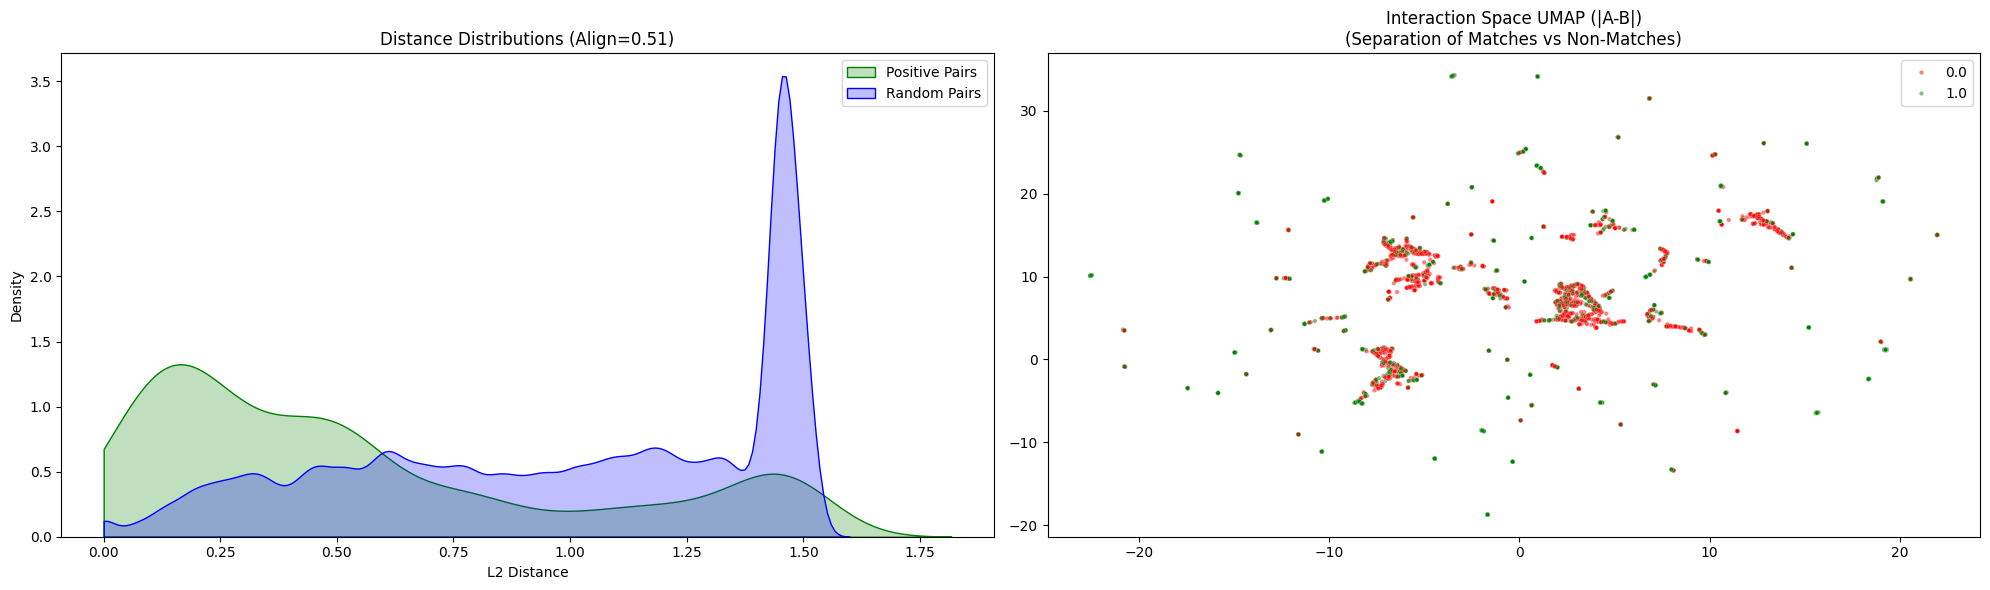

In [11]:
# --- 6. RUN ---
evaluate_finetuned_model(args)

## Running SVD on encoder embeddings to confirm dimensionality collapse

In [12]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import yaml
import argparse
from tqdm import tqdm
import os
import sys
from pathlib import Path
import copy

In [13]:
# --- 3. IMPORTS ---
cwd = Path.cwd()
cwd = cwd.parents[1]
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

%matplotlib inline

In [14]:
# --- 2. CONFIGURATION (Edit this!) ---
class Args:
    # PATHS
    test_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
    mol_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
    
    template_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
    custom_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    
    # POINT TO YOUR FINE-TUNED ENCODER
    finetuned_encoder_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/alignuniform/best_au_msgmona.pkl" 
    
    output_dir = "./results_svd"
    gpu_id = 0
    batch_size = 64

args = Args()

In [15]:
try:
    from classifier_siamesemodel_new import MassFormerEncoder 
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"❌ Error importing modules: {e}")

In [16]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [17]:
# --- 4. EXECUTION ---
def run_svd_analysis(args):
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    print("--- SVD DIMENSIONALITY COLLAPSE ANALYSIS ---")

    # A. LOAD MODEL
    print(f"Loading Configs...")
    with open(args.template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: custom_config = yaml.safe_load(f)
    full_config = merge_configs(template_config, custom_config)

    print(f"Loading Encoder from {args.finetuned_encoder_path}...")
    model = MassFormerEncoder(
        model_config=full_config.get('model', {}),
        checkpoint_path=None # We load weights manually below
    ).to(device)
    
    # Load Weights
    state_dict = torch.load(args.finetuned_encoder_path, map_location=device)
    if 'best_model_sd' in state_dict: state_dict = state_dict['best_model_sd']
    model.encoder.load_state_dict(state_dict, strict=False)
    model.eval()

    # B. LOAD DATA
    print("Loading Test Data for Embeddings...")
    ds = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    loader = torch.utils.data.DataLoader(ds, batch_size=args.batch_size, shuffle=False, collate_fn=binary_collate_fn, num_workers=4)

    # C. EXTRACT EMBEDDINGS
    print("Extracting 5000 random embeddings...")
    embeddings = []
    MAX_SAMPLES = 5000
    count = 0
    
    with torch.no_grad():
        for batch_A, _, _, _, _ in tqdm(loader):
            for k in batch_A: batch_A[k] = batch_A[k].to(device)
            
            # Get Raw Output
            h = model({'gf_v2_data': batch_A})
            
            # Normalize (Since SupCon optimizes on the Sphere)
            h = F.normalize(h, dim=1)
            
            embeddings.append(h.cpu())
            count += len(h)
            if count >= MAX_SAMPLES: break
    
    # Stack
    X = torch.cat(embeddings, dim=0).numpy()
    print(f"Data Matrix Shape: {X.shape}")

    # D. PERFORM SVD
    print("Computing SVD...")
    # Center the data
    X_centered = X - X.mean(axis=0)
    
    # U, S, Vh
    U, S, Vh = np.linalg.svd(X_centered, full_matrices=False)
    
    # E. METRICS
    # Eigenvalues = Singular Values squared / (N-1)
    eigvals = S ** 2 / (X.shape[0] - 1)
    explained_variance = eigvals / np.sum(eigvals)
    cumulative_variance = np.cumsum(explained_variance)
    
    # Effective Rank (Shannon Entropy)
    # p is the normalized singular value distribution
    p = S / np.sum(S)
    effective_rank = np.exp(-np.sum(p * np.log(p + 1e-10)))

    print("\n--- RESULTS ---")
    print(f"► Effective Rank: {effective_rank:.2f} (Max possible: {min(X.shape)})")
    print(f"► Top 1 Component Variance: {explained_variance[0]*100:.2f}%")
    print(f"► Top 5 Components Variance: {np.sum(explained_variance[:5])*100:.2f}%")

    # F. PLOTTING
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Log Singular Values
    axes[0].plot(np.log10(S), linewidth=2)
    axes[0].set_title("Singular Value Spectrum (Log Scale)\n(Steep Drop = Collapse)", fontsize=14)
    axes[0].set_xlabel("Component Index")
    axes[0].set_ylabel("Log10(Singular Value)")
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Cumulative Variance
    axes[1].plot(cumulative_variance, linewidth=2, color='orange')
    axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
    axes[1].set_title("Cumulative Explained Variance\n(Fast Rise = Collapse)", fontsize=14)
    axes[1].set_xlabel("Number of Components")
    axes[1].set_ylabel("Cumulative Variance")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Interpretation Text
    if explained_variance[0] > 0.5:
        plt.figtext(0.5, -0.05, "⚠️ WARNING: High Collapse Detected (Top 1 > 50%)", 
                    ha="center", fontsize=12, color="red", weight="bold")
    else:
        plt.figtext(0.5, -0.05, "✅ STATUS: Healthy Spectrum", 
                    ha="center", fontsize=12, color="green", weight="bold")

    plt.tight_layout()
    os.makedirs(args.output_dir, exist_ok=True)
    plt.savefig(os.path.join(args.output_dir, "svd_spectrum_jupyter.png"), dpi=150)
    plt.show()

--- SVD DIMENSIONALITY COLLAPSE ANALYSIS ---
Loading Configs...
Loading Encoder from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/alignuniform/best_au_msgmona.pkl...


/tmp/ipykernel_374564/568226460.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(args.finetuned_encoder_path, map_location=device)


Loading Test Data for Embeddings...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Extracting 5000 random embeddings...


100%|██████████| 76/76 [00:07<00:00, 10.68it/s]


Data Matrix Shape: (4858, 768)
Computing SVD...

--- RESULTS ---
► Effective Rank: 31.04 (Max possible: 768)
► Top 1 Component Variance: 45.23%
► Top 5 Components Variance: 89.00%


/tmp/ipykernel_374564/568226460.py:106: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(os.path.join(args.output_dir, "svd_spectrum_jupyter.png"), dpi=150)
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


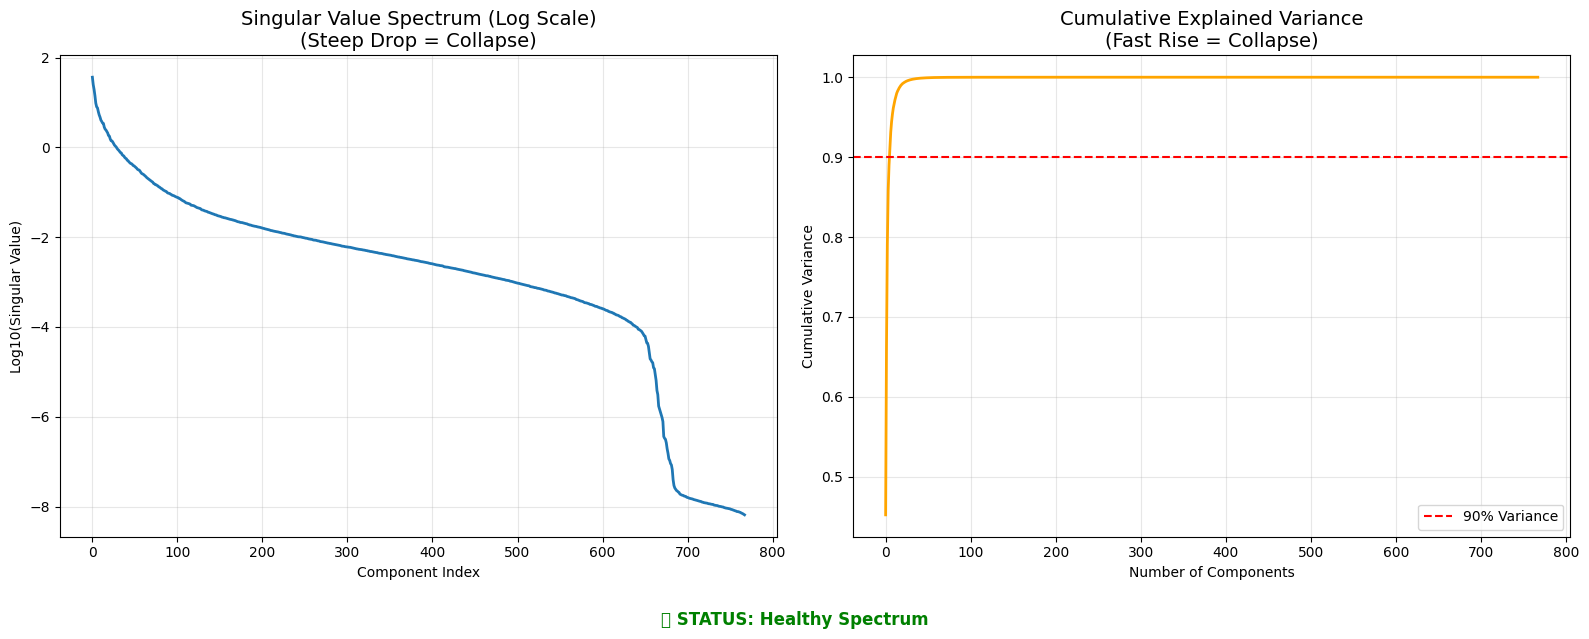

In [18]:
# --- 5. RUN ---
run_svd_analysis(args)

In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import pandas as pd
from tqdm import tqdm
import os
import sys
from collections import defaultdict
from pathlib import Path

In [16]:
# --- SETUP ---
class Args:
    # Update these paths!
    test_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
    mol_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
    
    template_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
    custom_config_path = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    
    # Your current best encoder
    finetuned_encoder_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/finetuned_encoder/vicreg/best_vicreg.pkl" 
    
    gpu_id = 0
    batch_size = 64
    margin = 0.2

args = Args()

In [17]:
# --- IMPORTS ---
cwd = Path.cwd()
sys.path.insert(0, os.path.join(cwd, 'data_loaders'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [18]:
try:
    from classifier_siamesemodel_new import MassFormerEncoder 
    from binary_data_loader import BinaryClassificationDataset, binary_collate_fn
except ImportError as e:
    print(f"❌ Error importing modules: {e}")

In [19]:
def merge_configs(base_config, custom_config):
    """
    Recursively merges the custom config into the base config.
    """
    merged_config = copy.deepcopy(base_config)
    for key, value in custom_config.items():
        if isinstance(value, dict) and key in merged_config and isinstance(merged_config[key], dict):
            merged_config[key] = merge_configs(merged_config[key], value)
        else:
            merged_config[key] = value
    return merged_config

In [20]:
def analyze_triplet_gap(args):
    device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")
    print("--- TRIPLETS: RELATIVE HARDNESS ANALYSIS ---")

    # 1. LOAD MODEL
    print("Loading Encoder...")
    with open(args.template_config_path, 'r') as f: template_config = yaml.safe_load(f)
    with open(args.custom_config_path, 'r') as f: custom_config = yaml.safe_load(f)
    full_config = merge_configs(template_config, custom_config)

    model = MassFormerEncoder(full_config.get('model', {}), checkpoint_path=None).to(device)
    state_dict = torch.load(args.finetuned_encoder_path, map_location=device)
    if 'best_model_sd' in state_dict: state_dict = state_dict['best_model_sd']
    model.encoder.load_state_dict(state_dict, strict=False)
    model.eval()

    # 2. LOAD DATA
    print("Loading Dataset...")
    ds = BinaryClassificationDataset(args.test_pairs_path, args.spec_data_path, args.mol_data_path)
    
    # 3. CONSTRUCT TRIPLETS (Anchor -> [Positives], [Negatives])
    # We need to find anchors that have BOTH a positive and a negative in the dataset
    print("Grouping pairs by Anchor...")
    anchor_to_pos = defaultdict(list)
    anchor_to_neg = defaultdict(list)
    
    # Iterate through the dataframe to build adjacency list
    # We'll limit to first 20k rows to save time if dataset is huge
    limit = 20000
    for idx, row in tqdm(ds.pairs_df.iloc[:limit].iterrows(), total=limit):
        anchor = row['name_main']
        target = row['name_sub']
        label = row['label']
        
        if label == 1:
            anchor_to_pos[anchor].append(idx)
        else:
            anchor_to_neg[anchor].append(idx)
            
    # Filter for Anchors that have at least 1 Pos and 1 Neg
    valid_anchors = [a for a in anchor_to_pos if a in anchor_to_neg]
    print(f"Found {len(valid_anchors)} Anchors with both Positive and Negative pairs.")
    
    if len(valid_anchors) == 0:
        print("⚠️ No valid triplets found in the first 20k rows. Try increasing limit or checking data labels.")
        return

    # 4. COMPUTE GAP
    # Gap = d(A, N) - d(A, P)
    gaps = []
    hard_count = 0
    semi_hard_count = 0
    easy_count = 0
    
    print("Computing Embeddings and Gaps...")
    
    # We process anchor-by-anchor (inefficient but safe) or batch if we reconstructed indices.
    # For simplicity, let's just grab the graph objects directly using dataset.__getitem__
    
    # Limit evaluation to 2000 triplets to be fast
    eval_limit = 2000
    
    # Pre-fetch indices to batch them
    triplet_indices = []
    for anchor in valid_anchors:
        # For each anchor, pick 1 random positive and 1 random negative
        p_idx = np.random.choice(anchor_to_pos[anchor])
        n_idx = np.random.choice(anchor_to_neg[anchor])
        triplet_indices.append((p_idx, n_idx))
        if len(triplet_indices) >= eval_limit: break
            
    # Custom Batching Loop
    batch_size = 16
    for i in tqdm(range(0, len(triplet_indices), batch_size)):
        batch_tuples = triplet_indices[i : i+batch_size]
        
        # We need to manually collate. 
        # Note: DS[idx] returns (gA, gB, meta, md, label)
        # We need A, P (from p_idx) and N (from n_idx)
        
        graphs_A = []
        graphs_P = []
        graphs_N = []
        
        for p_idx, n_idx in batch_tuples:
            # Get Positive Pair (A, P)
            item_p = ds[p_idx] 
            graphs_A.append(item_p[0]) # Anchor
            graphs_P.append(item_p[1]) # Positive
            
            # Get Negative Pair (A, N) - A should be same (check implied)
            item_n = ds[n_idx]
            graphs_N.append(item_n[1]) # Negative
            
        # Collate
        if len(graphs_A) == 0: continue
        batch_A = binary_collate_fn([(g, g, torch.zeros(1), torch.zeros(1), torch.zeros(1)) for g in graphs_A])[0]
        batch_P = binary_collate_fn([(g, g, torch.zeros(1), torch.zeros(1), torch.zeros(1)) for g in graphs_P])[0]
        batch_N = binary_collate_fn([(g, g, torch.zeros(1), torch.zeros(1), torch.zeros(1)) for g in graphs_N])[0]
        
        # Move to GPU
        for k in batch_A: batch_A[k] = batch_A[k].to(device)
        for k in batch_P: batch_P[k] = batch_P[k].to(device)
        for k in batch_N: batch_N[k] = batch_N[k].to(device)
        
        with torch.no_grad():
            emb_A = F.normalize(model({'gf_v2_data': batch_A}), dim=1)
            emb_P = F.normalize(model({'gf_v2_data': batch_P}), dim=1)
            emb_N = F.normalize(model({'gf_v2_data': batch_N}), dim=1)
            
            # Distances (Euclidean on Sphere)
            d_ap = (emb_A - emb_P).norm(dim=1)
            d_an = (emb_A - emb_N).norm(dim=1)
            
            gap = d_an - d_ap
            gaps.extend(gap.cpu().numpy())

    # 5. PLOT
    gaps = np.array(gaps)
    
    # Categorize
    hard = gaps < 0
    semi_hard = (gaps >= 0) & (gaps < args.margin)
    easy = gaps >= args.margin
    
    print("\n--- HARDNESS BREAKDOWN ---")
    print(f"HARD (Neg closer than Pos):      {np.sum(hard)} ({np.mean(hard)*100:.1f}%)")
    print(f"SEMI-HARD (Inside Margin):       {np.sum(semi_hard)} ({np.mean(semi_hard)*100:.1f}%)")
    print(f"EASY (Safe distance):            {np.sum(easy)} ({np.mean(easy)*100:.1f}%)")
    
    plt.figure(figsize=(10, 6))
    sns.histplot(gaps, bins=50, kde=True, element="step")
    
    # Zones
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0)')
    plt.axvline(x=args.margin, color='green', linestyle='--', linewidth=2, label=f'Margin ({args.margin})')
    
    # Shading
    ylim = plt.ylim()
    plt.fill_betweenx(ylim, -2, 0, color='red', alpha=0.1, label='Hard Zone (Gradient++)')
    plt.fill_betweenx(ylim, 0, args.margin, color='orange', alpha=0.1, label='Semi-Hard Zone (Gradient+)')
    plt.fill_betweenx(ylim, args.margin, 2, color='green', alpha=0.1, label='Easy Zone (Gradient=0)')
    
    plt.title(f"Triplet Gap Distribution (Margin={args.margin})")
    plt.xlabel("Gap = dist(Anchor, Neg) - dist(Anchor, Pos)")
    plt.ylabel("Count")
    plt.legend(loc='upper left')
    plt.xlim(-0.5, 1.0) # Zoom in on the interesting area
    
    plt.tight_layout()
    plt.savefig("triplet_hardness_analysis.png")
    plt.show()

--- TRIPLETS: RELATIVE HARDNESS ANALYSIS ---
Loading Encoder...


/tmp/ipykernel_1946976/1824706039.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(args.finetuned_encoder_path, map_location=device)


Loading Dataset...
Loading binary pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather...
Loading spectral data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Loading molecular data from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl...
Initializing Fixed Metadata Encoder (Inst + Adduct)...
NCE Normalization: Mean=64.69, Std=40.55
Grouping pairs by Anchor...


100%|██████████| 20000/20000 [00:00<00:00, 67092.33it/s]


Found 1452 Anchors with both Positive and Negative pairs.
Computing Embeddings and Gaps...


100%|██████████| 91/91 [00:19<00:00,  4.66it/s]



--- HARDNESS BREAKDOWN ---
HARD (Neg closer than Pos):      361 (24.9%)
SEMI-HARD (Inside Margin):       1069 (73.6%)
EASY (Safe distance):            22 (1.5%)


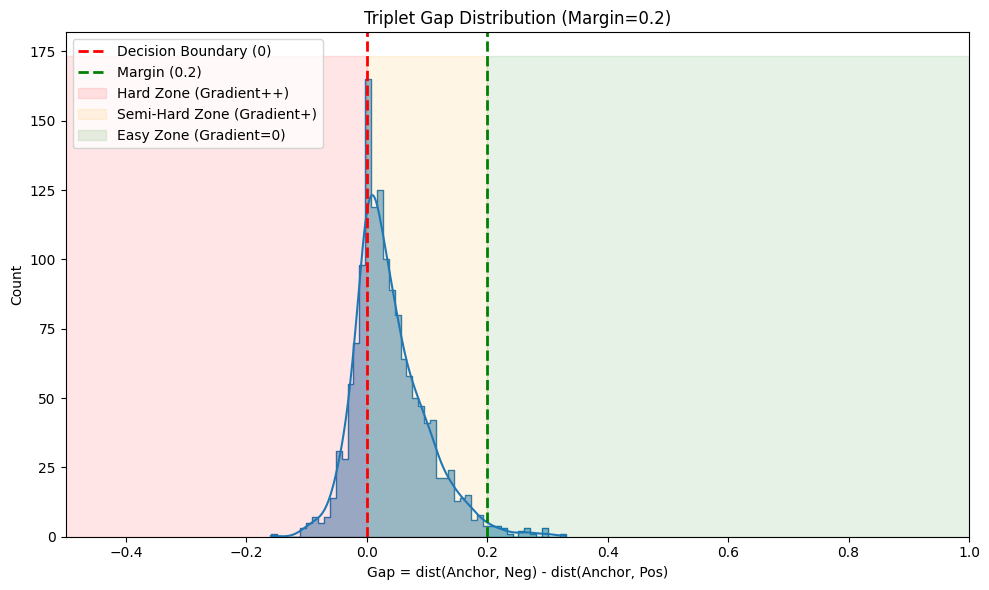

In [21]:
if __name__ == '__main__':
    analyze_triplet_gap(args)

## Inspecting ground truth manifold

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
from scipy.spatial.distance import squareform
import seaborn as sns
from tqdm import tqdm
import plotly.express as px

In [49]:
# --- 1. CONFIGURATION ---
PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/mass_gate_2_percent/temp_subset_0.02_stratified_binary_07_spec_sim_dataset_train.feather"
# We need a column that represents the continuous score (0.0 to 1.0).
# If your dataframe only has 'label' (0/1), we can use that, but 'score' is better if available.
SCORE_COL = 'cosine_similarity'  
SUBSET_SIZE = 100000

In [50]:
# --- 2. LOAD DATA ---
print(f"Loading pairs from {PAIRS_PATH}...")
df = pd.read_feather(PAIRS_PATH)

# Check if score column exists, otherwise use label
if SCORE_COL not in df.columns:
    print(f"⚠️ Warning: '{SCORE_COL}' column not found. Using 'label' as proxy for similarity.")
    SCORE_COL = 'label'

Loading pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/mass_gate_2_percent/temp_subset_0.02_stratified_binary_07_spec_sim_dataset_train.feather...


In [51]:
# --- 3. FILTER SUBSET (Dense Connection Strategy) ---
# To make a good map, we want molecules that have connections in the dataset.
# We pick the top N spectra that appear most frequently in the pairs list.
print("Selecting representative subset...")
all_ids = pd.concat([df['name_main'], df['name_sub']])
top_ids = all_ids.value_counts().head(SUBSET_SIZE).index.tolist()
valid_ids = set(top_ids)

# Filter dataframe to only include rows where BOTH items are in our subset
subset_df = df[
    (df['name_main'].isin(valid_ids)) & 
    (df['name_sub'].isin(valid_ids))
].copy()

print(f"Subset Stats: {len(valid_ids)} unique spectra, {len(subset_df)} pairwise relations.")

Selecting representative subset...
Subset Stats: 100000 unique spectra, 2359768 pairwise relations.


In [52]:
# --- 4. CONSTRUCT DISTANCE MATRIX ---
# Initialize Distance Matrix with 1.0 (Maximum Distance / Dissimilar)
# D_ij = 1.0 - Similarity
print("Building N x N Distance Matrix...")
id_to_idx = {spec_id: i for i, spec_id in enumerate(top_ids)}
n = len(top_ids)
dist_matrix = np.ones((n, n), dtype=np.float32)

# Set diagonal to 0 (Self-distance)
np.fill_diagonal(dist_matrix, 0.0)

# Fill Matrix
# Iterate through the subset pairs and update distances
for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
    idx_i = id_to_idx[row['name_main']]
    idx_j = id_to_idx[row['name_sub']]
    
    # Distance = 1 - Similarity
    # Clamp score between 0 and 1 just in case
    sim = max(0.0, min(1.0, row[SCORE_COL]))
    dist = 1.0 - sim
    
    # Update both sides (Symmetric)
    dist_matrix[idx_i, idx_j] = dist
    dist_matrix[idx_j, idx_i] = dist

print("Matrix built. Shape:", dist_matrix.shape)

Building N x N Distance Matrix...


100%|██████████| 2359768/2359768 [00:35<00:00, 66769.43it/s]

Matrix built. Shape: (100000, 100000)


In [53]:
# --- 5. RUN UMAP (Manifold Learning) ---
print("Running UMAP (this may take a minute)...")
reducer = umap.UMAP(
    metric='precomputed', # <--- CRITICAL: We tell UMAP we already have distances
    n_components=3,       # 2D projection
    n_neighbors=15,       # Local neighborhood size (15-30 is standard)
    min_dist=0.1,         # How tightly to pack points
    random_state=42
)

embedding = reducer.fit_transform(dist_matrix)

Running UMAP (this may take a minute)...


/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/umap/umap_.py:1865: UserWarning:

using precomputed metric; inverse_transform will be unavailable

/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [54]:
# --- 5. INTERACTIVE 3D VISUALIZATION (PLOTLY) ---
print("Generating interactive plot...")

# Convert to DataFrame
plot_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2', 'UMAP3'])
plot_df['spec_id'] = top_ids

fig = px.scatter_3d(
    plot_df,
    x='UMAP1',
    y='UMAP2',
    z='UMAP3',
    color='UMAP3', 
    
    # --- FIX IS HERE ---
    # Use 'Viridis' (Safe bet) or 'px.colors.diverging.Spectral'
    color_continuous_scale='Viridis', 
    
    hover_name='spec_id',
    title=f'Interactive 3D Ground Truth Spectral Manifold (N={len(top_ids)})',
    opacity=0.7,
    width=1000,
    height=800
)

fig.update_traces(marker=dict(size=3))
fig.show()

# --- 7. ANALYSIS HELPER ---
print("\n--- HOW TO INTERPRET FOR A-U FINETUNING ---")
print("1. CLUMPY (Islands): If you see distinct, separated blobs:")
print("   -> GOOD for A-U. The data naturally forms clusters (chemical families).")
print("   -> A-U will align items within blobs and use Uniformity to push blobs apart.")
print("\n2. UNIFORM BLOB (Hairball): If you see one giant connected cloud:")
print("   -> CAUTION. The spectral similarities are continuous and lack clear boundaries.")
print("   -> Setting 'lambda_unif' too high might force artificial separation where none exists.")

Generating interactive plot...



--- HOW TO INTERPRET FOR A-U FINETUNING ---
1. CLUMPY (Islands): If you see distinct, separated blobs:
   -> GOOD for A-U. The data naturally forms clusters (chemical families).
   -> A-U will align items within blobs and use Uniformity to push blobs apart.

2. UNIFORM BLOB (Hairball): If you see one giant connected cloud:
   -> CAUTION. The spectral similarities are continuous and lack clear boundaries.
   -> Setting 'lambda_unif' too high might force artificial separation where none exists.


## Compare embeddings to ground truth manifold

In [45]:
import torch
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
from scipy.spatial import procrustes
import scipy.linalg

# --- MONKEYPATCH FIX FOR SKLEARN ---
# Scipy 1.7+ removed pinv2, but old sklearn versions still need it.
# We map pinv2 to pinv manually to fix the crash.
if not hasattr(scipy.linalg, 'pinv2'):
    scipy.linalg.pinv2 = scipy.linalg.pinv
    print("✅ Applied 'pinv2' patch for Scikit-Learn.")
    
# NOW import the rest
from sklearn.cross_decomposition import CCA
from tqdm.notebook import tqdm
import sys
import os
from pathlib import Path
import yaml
from tqdm import tqdm

In [46]:
# --- IMPORTS ---
cwd = Path.cwd()
cwd = cwd.parents[1]

In [47]:
cwd

PosixPath('/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor')

In [48]:
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'AlignUniform'))
sys.path.insert(0, os.path.join(cwd, 'model'))
sys.path.insert(0, os.path.join(os.path.dirname(cwd.parent), 'tmach007/massformer/src/massformer'))

In [49]:
try:
    from classifier_siamesemodel_new import MassFormerEncoder
    from finetune_dataloader_au import AlignUniformDataset, au_collate_fn
except ImportError as e:
    sys.exit(f"Error: {e}")

In [75]:
# --- 2. CONFIGURATION ---
class ValidationArgs:
    val_pairs_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_val.feather"
    spec_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_COMBINED.pkl"
    mol_data_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df_COMBINED.pkl"
    
    template_config = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml" 
    custom_config = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
    checkpoint_path = "/data/nas-gpu/wang/tmach007/massformer/checkpoints/demo.pkl"
    
    subset_size = 3000
    batch_size = 32
    gpu_id = 0
    score_col = 'cosine_similarity'

args = ValidationArgs()
device = torch.device(f"cuda:{args.gpu_id}" if torch.cuda.is_available() else "cpu")

In [76]:
# --- 3. PREPARE CONNECTED SUBSET ---
print("--- 1. Selecting Connected Subset ---")
df = pd.read_feather(args.val_pairs_path)

# To ensure the manifold is valid, we pick the N spectra with the MOST connections.
# Random selection would result in a matrix of mostly 1.0s (disconnected).
all_ids = pd.concat([df['name_main'], df['name_sub']])
top_ids = all_ids.value_counts().head(args.subset_size).index.tolist()
subset_specs = sorted(list(set(top_ids)))

print(f"Selected {len(subset_specs)} spectra for analysis.")

# Filter the dataframe to only relevant pairs for speed
subset_df = df[
    (df['name_main'].isin(subset_specs)) & 
    (df['name_sub'].isin(subset_specs))
].copy()

# Create lookup for fast indexing
id_to_idx = {spec_id: i for i, spec_id in enumerate(subset_specs)}

--- 1. Selecting Connected Subset ---
Selected 2182 spectra for analysis.


In [77]:
# --- 4. GENERATE GROUND TRUTH MANIFOLD (From 'cosine_similarity') ---
print("\n--- 2. Generating Ground Truth UMAP (From Dataframe) ---")

# Initialize Distance Matrix with 1.0 (Maximum Distance)
n = len(subset_specs)
gt_dist_matrix = np.ones((n, n), dtype=np.float32)
np.fill_diagonal(gt_dist_matrix, 0.0)

# Fill with actual scores
for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Building Matrix"):
    idx_i = id_to_idx[row['name_main']]
    idx_j = id_to_idx[row['name_sub']]
    
    # Distance = 1.0 - Similarity
    sim = max(0.0, min(1.0, row[args.score_col]))
    dist = 1.0 - sim
    
    gt_dist_matrix[idx_i, idx_j] = dist
    gt_dist_matrix[idx_j, idx_i] = dist

# Run UMAP
print("Running UMAP on Ground Truth Matrix...")
gt_reducer = umap.UMAP(metric='precomputed', n_components=3, random_state=42)
gt_umap_3d = gt_reducer.fit_transform(gt_dist_matrix)


--- 2. Generating Ground Truth UMAP (From Dataframe) ---


Building Matrix: 100%|██████████| 4956/4956 [00:00<00:00, 65696.73it/s]

Running UMAP on Ground Truth Matrix...



/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [78]:
# --- 5. GENERATE MODEL EMBEDDING MANIFOLD ---
print("\n--- 3. Generating Model Embeddings ---")

try:
    from gf_data_utils import gf_preprocess, collator
except ImportError as e:
    print(f"Error: {e}")

# Load Dataset Wrappers (for molecule lookup)
full_dataset = AlignUniformDataset(args.val_pairs_path, args.spec_data_path, args.mol_data_path)

# Load Model
with open(args.template_config, 'r') as f: tc = yaml.safe_load(f)
with open(args.custom_config, 'r') as f: cc = yaml.safe_load(f)
conf = merge_configs(tc, cc)

model = MassFormerEncoder(conf.get('model', {}), checkpoint_path=None).to(device)
ckpt = torch.load(args.checkpoint_path, map_location=device)
model.encoder.load_state_dict(ckpt['best_model_sd'], strict=False)
model.eval()

# Inference Loop (FIXED)
model_embeddings = []
batch_graphs = []

with torch.no_grad():
    for i, spec_id in enumerate(tqdm(subset_specs, desc="Inference")):
        # Lookup Mol from Spec ID
        mol_id = full_dataset.spec_lookup.loc[spec_id, 'mol_id']
        mol = full_dataset.mol_lookup.loc[mol_id, 'mol']
        
        # Preprocess
        graph = gf_preprocess(mol, i)
        batch_graphs.append(graph)
        
        if len(batch_graphs) == args.batch_size or i == len(subset_specs) - 1:
            # 1. Collate
            batch = collator(batch_graphs)
            # 2. Move to Device (Manual Dict Handling)
            for k in batch:
                batch[k] = batch[k].to(device)
                
            # 3. Forward
            emb = model({'gf_v2_data': batch}) 
            model_embeddings.append(emb.cpu().numpy())
            batch_graphs = []

model_embeddings = np.vstack(model_embeddings)

# UMAP Model (Cosine metric is standard for embeddings)
print("Running UMAP on Model Embeddings...")
model_reducer = umap.UMAP(metric='cosine', n_components=3, random_state=42)
model_umap_3d = model_reducer.fit_transform(model_embeddings)


--- 3. Generating Model Embeddings ---
Loading pairs from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_val.feather...
Filtered for Positive Pairs: 2478


/tmp/ipykernel_1946976/3190731964.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(args.checkpoint_path, map_location=device)
Inference: 100%|█████████

Running UMAP on Model Embeddings...


In [81]:
# --- 6. PROCRUSTES & CCA ---
print("\n--- 4. Alignment & Metrics ---")
mtx1, mtx2, disparity = procrustes(gt_umap_3d, model_umap_3d)
print(f"► Procrustes Disparity: {disparity:.4f} (Lower is better)")

cca = CCA(n_components=3)
cca.fit(gt_umap_3d, model_umap_3d)
X_c, Y_c = cca.transform(gt_umap_3d, model_umap_3d)
correlations = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(3)]
print(f"► CCA Correlation: {np.mean(correlations):.4f} (Higher is better)")


--- 4. Alignment & Metrics ---
► Procrustes Disparity: 0.9819 (Lower is better)
► CCA Correlation: 0.1242 (Higher is better)


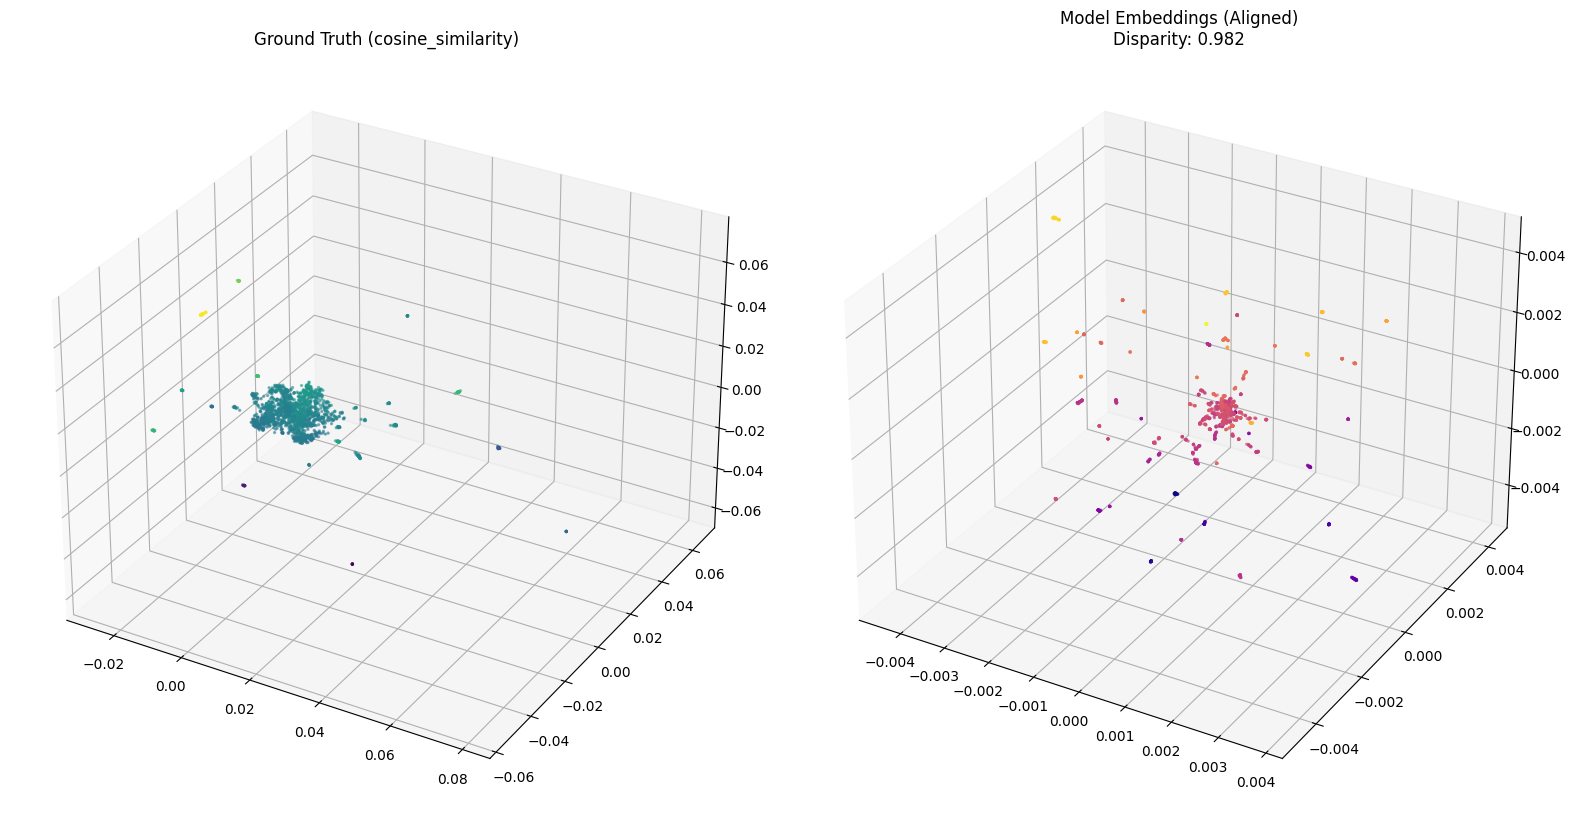

In [82]:
# --- 7. VISUALIZATION ---
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(mtx1[:,0], mtx1[:,1], mtx1[:,2], c=mtx1[:,2], cmap='viridis', s=2, alpha=0.5)
ax1.set_title(f"Ground Truth ({args.score_col})")

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(mtx2[:,0], mtx2[:,1], mtx2[:,2], c=mtx2[:,2], cmap='plasma', s=2, alpha=0.5)
ax2.set_title(f"Model Embeddings (Aligned)\nDisparity: {disparity:.3f}")

plt.tight_layout()
plt.show()